# Astrocyte single-cell RNA-seq: a training re-analysis of GSE114000 with Scanpy

**What this is.** A self-directed training exercise in single-cell RNA-seq analysis.
It re-analyses the public Smart-seq2 dataset of adult mouse cortex and hippocampus
astrocytes from Batiuk, Martirosyan et al., *Nature Communications* 2020
(GEO accession GSE114000) and checks how far a standard Scanpy workflow recovers
the cell types and astrocyte subtypes (AST1 to AST5) that the authors published.

**What this is not.** It is not new biology and not a replication of the paper's
own pipeline. The authors' labels are used only at the end, as a reference to
compare against.

Steps: load counts and metadata, quality control, normalisation, highly variable
genes, PCA, neighbour graph, UMAP, Leiden clustering, marker genes, cell-type
annotation, astrocyte sub-clustering, comparison with the published labels.

## 0. Setup

This cell makes the notebook self-contained: it installs the packages if they
are missing (for example in Google Colab) and downloads the two GEO files
(about 12.5 MB) into `data/` if they are not there yet.

In [1]:
import importlib.util
import subprocess
import sys
import urllib.request
from pathlib import Path

if importlib.util.find_spec("scanpy") is None or importlib.util.find_spec("leidenalg") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scanpy", "leidenalg", "igraph", "openpyxl"])

GEO = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE114nnn/GSE114000/suppl/"
GEO_FILES = [
    "GSE114000_Counts_Batiuk_Martirosyan_Supplementary_Data3.tsv.gz",
    "GSE114000_Metadata_Batiuk_Martirosyan_Supplementary_Data1.xlsx",
]
Path("data").mkdir(exist_ok=True)
for name in GEO_FILES:
    target = Path("data") / name
    if not target.exists():
        print("downloading", name)
        urllib.request.urlretrieve(GEO + name, target)
    print(f"{name}: {target.stat().st_size:,} bytes")

GSE114000_Counts_Batiuk_Martirosyan_Supplementary_Data3.tsv.gz: 12,440,007 bytes
GSE114000_Metadata_Batiuk_Martirosyan_Supplementary_Data1.xlsx: 134,038 bytes


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

SEED = 0
np.random.seed(SEED)
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, dpi_save=200, frameon=False, figsize=(4.5, 4))

ROOT = Path(".")
DATA = ROOT / "data"
FIG = ROOT / "figures"
RES = ROOT / "results"
FIG.mkdir(exist_ok=True)
RES.mkdir(exist_ok=True)

COUNTS = DATA / "GSE114000_Counts_Batiuk_Martirosyan_Supplementary_Data3.tsv.gz"
META = DATA / "GSE114000_Metadata_Batiuk_Martirosyan_Supplementary_Data1.xlsx"
print("scanpy", sc.__version__, "| anndata", ad.__version__)

scanpy 1.12.4 | anndata 0.13.4


## 1. Load the count matrix and the published metadata

The count file is genes by cells (HTSeq counts, one Smart-seq2 library per cell).
Scanpy expects cells by genes, so the table is transposed. The metadata sheet
gives the brain area, plate and the authors' cell-type label for every cell.

In [3]:
counts = pd.read_csv(COUNTS, sep="\t", skiprows=2, index_col=0)
meta = pd.read_excel(META, header=1)
meta["Cell ID"] = meta["Cell ID"].astype(str).str.replace(r"^X", "", regex=True)
meta = meta.set_index("Cell ID")
print("counts (genes x cells):", counts.shape)
print("metadata rows:", meta.shape[0])
print("cells in both:", len(set(counts.columns) & set(meta.index)))

adata = ad.AnnData(X=sparse.csr_matrix(counts.T.values.astype(np.float32)))
adata.obs_names = counts.columns.astype(str)
adata.var_names = counts.index.astype(str)
adata.var_names_make_unique()
adata.obs["region"] = meta.reindex(adata.obs_names)["Brain area"].astype(str).values
adata.obs["plate"] = meta.reindex(adata.obs_names)["Plate name"].astype(str).values
adata.obs["sample"] = meta.reindex(adata.obs_names)["Sample name"].astype(str).values
adata.obs["published_type"] = meta.reindex(adata.obs_names)["Type"].astype(str).values
adata

counts (genes x cells): (49660, 2031)
metadata rows: 2031
cells in both: 2031


AnnData object with n_obs × n_vars = 2031 × 49660
    obs: 'region', 'plate', 'sample', 'published_type'
    layers: None (.X)

In [4]:
print(adata.obs["region"].value_counts().to_string())
print()
print(adata.obs["published_type"].value_counts().to_string())

region
Cortex         1062
Hippocampus     969

published_type
AST1                661
AST2                573
AST3                460
Mural               137
AST4                 91
Endothelial          30
AST5                 26
Neuronal             17
(none)               16
Microglial           11
Oligodendrocytic      9


## 2. Quality control

Three gene sets are flagged: mitochondrial genes (`mt-`), ERCC spike-ins and
ribosomal protein genes. For each cell we compute the number of detected genes,
the total counts and the share of counts from mitochondrial genes and spike-ins.
A high mitochondrial or spike-in share usually means a damaged or empty well.

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ercc"] = adata.var_names.str.startswith("ERCC-")
adata.var["ribo"] = adata.var_names.str.match(r"^Rp[sl]\d")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ercc", "ribo"], percent_top=None, log1p=True, inplace=True)
qc_cols = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ercc"]
print(adata.obs[qc_cols].describe().round(2).to_string())

       n_genes_by_counts  total_counts  pct_counts_mt  pct_counts_ercc
count            2031.00       2031.00        2031.00          2031.00
mean             2169.63    1592524.25           3.70             4.91
std               474.68     491666.91           1.63             2.04
min              1037.00     636910.00           0.53             1.43
25%              1823.50    1227274.50           2.62             3.43
50%              2134.00    1542867.00           3.47             4.50
75%              2501.00    1901321.50           4.46             5.91
max              3219.00    3307404.00          19.44            12.69


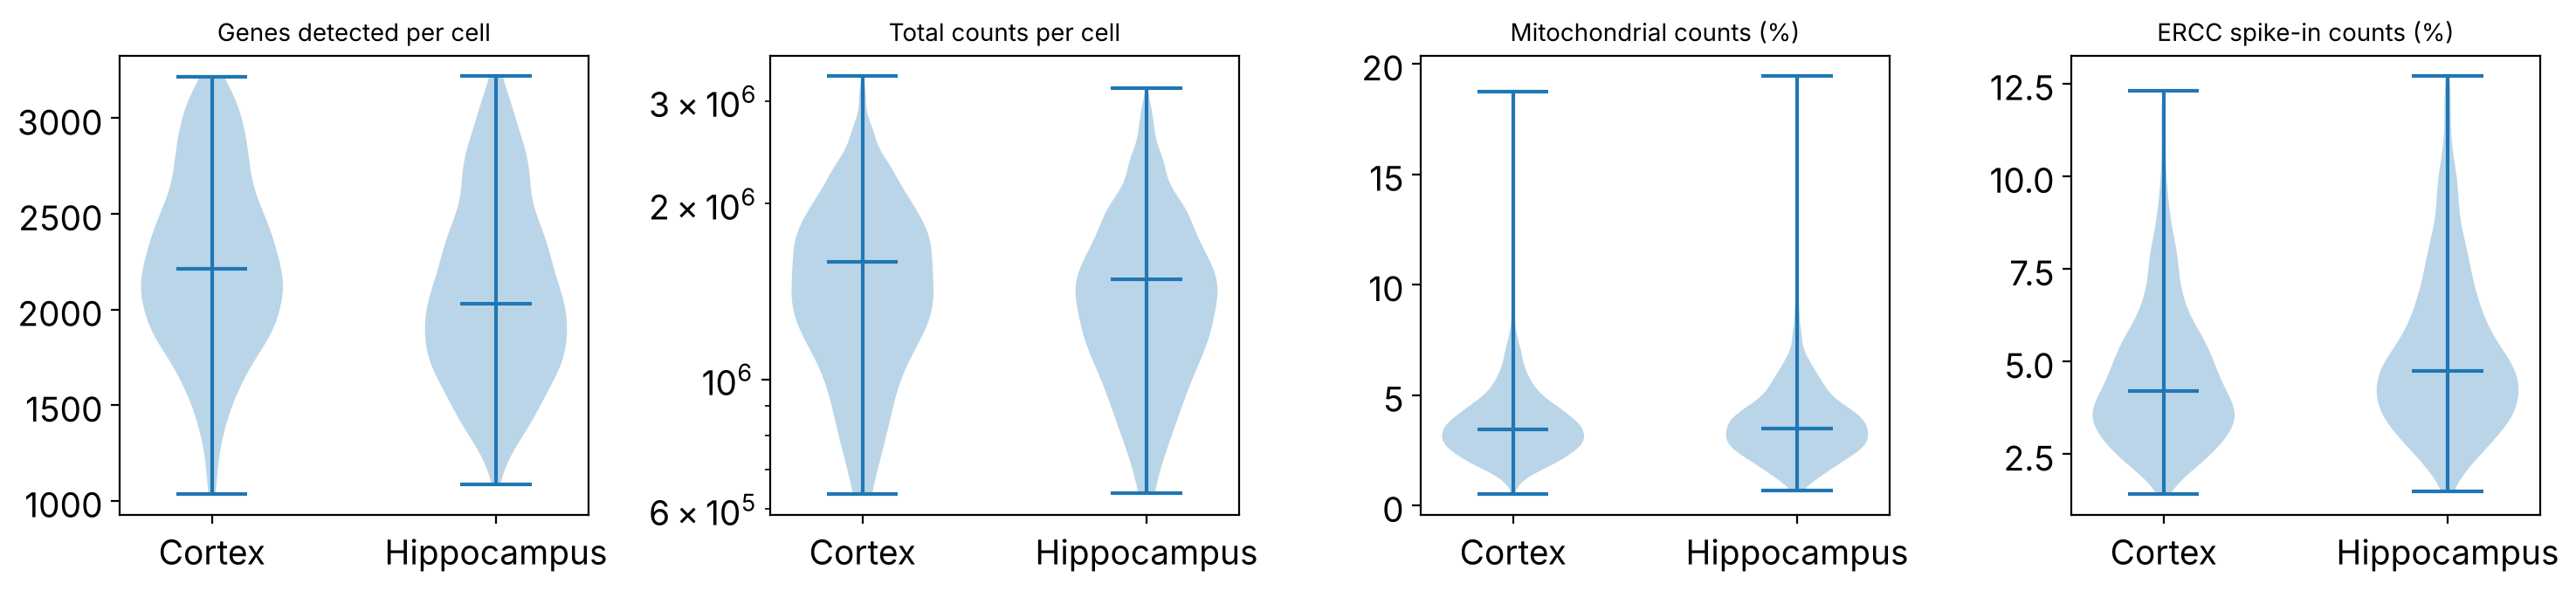

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
titles = ["Genes detected per cell", "Total counts per cell", "Mitochondrial counts (%)", "ERCC spike-in counts (%)"]
for ax, col, title in zip(axes, qc_cols, titles):
    parts = [adata.obs.loc[adata.obs["region"] == r, col].values for r in ["Cortex", "Hippocampus"]]
    ax.violinplot(parts, showmedians=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Cortex", "Hippocampus"])
    ax.set_title(title, fontsize=10)
    if col == "total_counts":
        ax.set_yscale("log")
    ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / "01_qc_violin.png", dpi=200, bbox_inches="tight")
plt.show()

### Filtering

The authors already removed low-quality libraries before depositing the data,
so the thresholds here are deliberately mild and data-driven: a cell is removed
when it is an outlier by more than 5 median absolute deviations (MAD) on the log
number of genes or log total counts, or when its mitochondrial share is more
than 5 MADs above the median. Genes seen in fewer than 5 cells are dropped, and
the spike-ins are removed after QC because they are not biological signal.

In [7]:
def mad_outlier(values, nmads, side="both"):
    med = np.median(values)
    mad = np.median(np.abs(values - med))
    lower = values < med - nmads * mad
    upper = values > med + nmads * mad
    return {"both": lower | upper, "upper": upper, "lower": lower}[side]

adata.obs["outlier_depth"] = mad_outlier(adata.obs["log1p_total_counts"].values, 5) | mad_outlier(
    adata.obs["log1p_n_genes_by_counts"].values, 5
)
adata.obs["outlier_mt"] = mad_outlier(adata.obs["pct_counts_mt"].values, 5, side="upper")
n_before = adata.n_obs
print("depth/complexity outliers:", int(adata.obs["outlier_depth"].sum()))
print("mitochondrial outliers:", int(adata.obs["outlier_mt"].sum()))
adata = adata[~(adata.obs["outlier_depth"] | adata.obs["outlier_mt"])].copy()
adata = adata[:, ~adata.var["ercc"]].copy()
sc.pp.filter_genes(adata, min_cells=5)
print(f"cells kept: {adata.n_obs} of {n_before}; genes kept: {adata.n_vars}")

depth/complexity outliers: 0
mitochondrial outliers: 30
cells kept: 2001 of 2031; genes kept: 19980


## 3. Normalisation and feature selection

Counts are scaled to the median library size and log-transformed. The 2,000
most variable genes are then selected for dimensionality reduction. The raw
counts stay in a separate layer.

In [8]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
print("highly variable genes:", int(adata.var["highly_variable"].sum()))

highly variable genes: 2000


## 4. PCA, neighbour graph, UMAP and Leiden clustering

In [9]:
sc.tl.pca(adata, n_comps=50, mask_var="highly_variable", random_state=SEED)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=SEED)
sc.tl.umap(adata, random_state=SEED)
sc.tl.leiden(adata, resolution=0.6, key_added="leiden", flavor="igraph", n_iterations=2, directed=False, random_state=SEED)
print(adata.obs["leiden"].value_counts().sort_index().to_string())

leiden
0    138
1    663
2    481
3    482
4     88
5     31
6     81
7     17
8      9
9     11


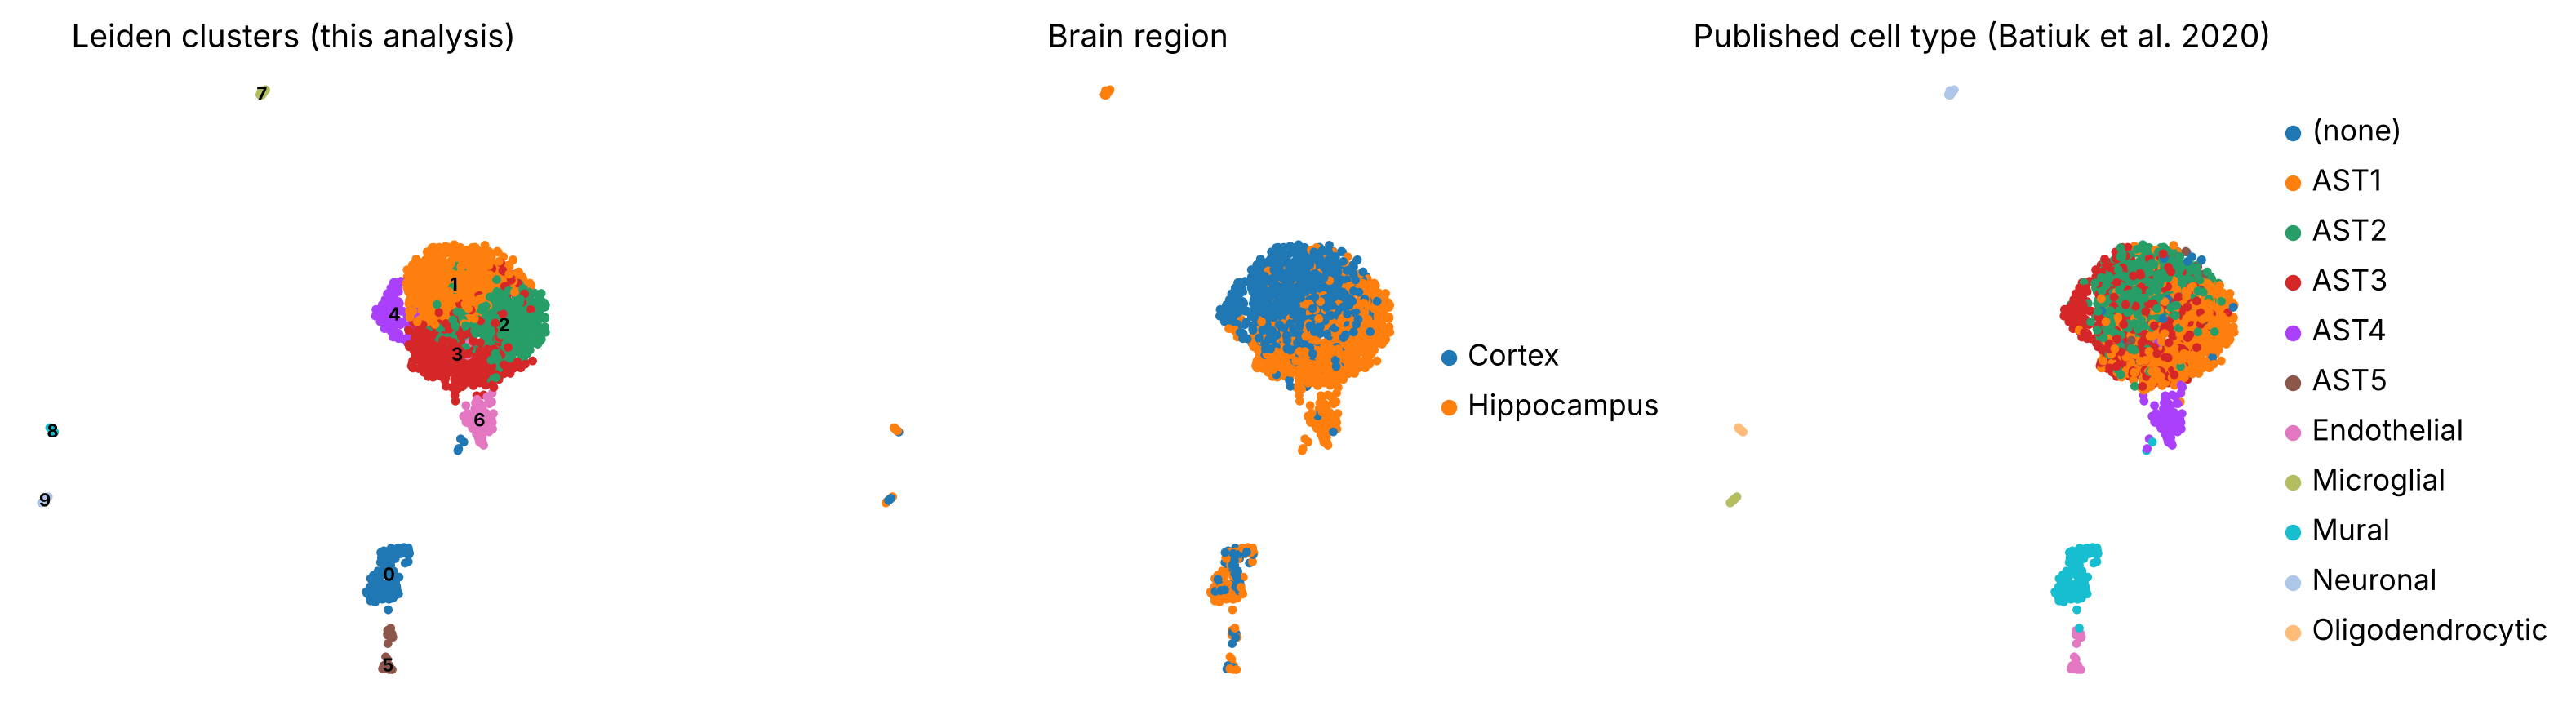

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, title="Leiden clusters (this analysis)", legend_loc="on data", legend_fontsize=8)
sc.pl.umap(adata, color="region", ax=axes[1], show=False, title="Brain region")
sc.pl.umap(adata, color="published_type", ax=axes[2], show=False, title="Published cell type (Batiuk et al. 2020)")
fig.tight_layout()
fig.savefig(FIG / "02_umap_all_cells.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Which cell type is each cluster?

Clusters are named from canonical marker genes, without looking at the
published labels. Each cluster gets the cell type whose markers have the
highest mean scaled expression in it.

In [11]:
MARKERS = {
    "Astrocyte": ["Aldoc", "Aqp4", "Gja1", "Slc1a3", "Slc1a2", "Aldh1l1"],
    "Neuron": ["Snap25", "Syt1", "Rbfox3", "Stmn2"],
    "Oligodendrocyte": ["Mbp", "Plp1", "Mog", "Mobp"],
    "OPC": ["Pdgfra", "Cspg4", "Olig1"],
    "Microglia/macrophage": ["Cx3cr1", "C1qa", "P2ry12", "Csf1r"],
    "Endothelial": ["Cldn5", "Flt1", "Pecam1"],
    "Mural": ["Pdgfrb", "Rgs5", "Kcnj8", "Acta2"],
    "Ependymal": ["Foxj1", "Ccdc153", "Tmem212"],
}
MARKERS = {k: [g for g in v if g in adata.var_names] for k, v in MARKERS.items()}

for name, genes in MARKERS.items():
    sc.tl.score_genes(adata, genes, score_name=f"score_{name}", random_state=SEED)
score_cols = [f"score_{k}" for k in MARKERS]
cluster_scores = adata.obs.groupby("leiden", observed=True)[score_cols].mean()
cluster_scores.columns = list(MARKERS)
cluster_call = cluster_scores.idxmax(axis=1)
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_call).astype("category")
print(cluster_scores.round(2).assign(call=cluster_call).to_string())

        Astrocyte  Neuron  Oligodendrocyte   OPC  Microglia/macrophage  Endothelial  Mural  Ependymal                  call
leiden                                                                                                                     
0           -2.46   -0.13            -0.15  1.53                 -0.22         0.41   5.71       0.00                 Mural
1            3.02   -0.01            -0.01  0.21                 -0.08        -0.13  -0.44      -0.01             Astrocyte
2            3.09   -0.05             0.00 -0.20                 -0.03        -0.14  -0.46       0.02             Astrocyte
3            3.11   -0.04            -0.01  0.33                 -0.07        -0.11  -0.51      -0.01             Astrocyte
4            3.03    0.01            -0.06 -0.19                 -0.10        -0.17  -0.60       0.04             Astrocyte
5           -2.70   -0.28            -0.29 -0.43                 -0.37         7.67   3.23      -0.08           Endothelial
6       

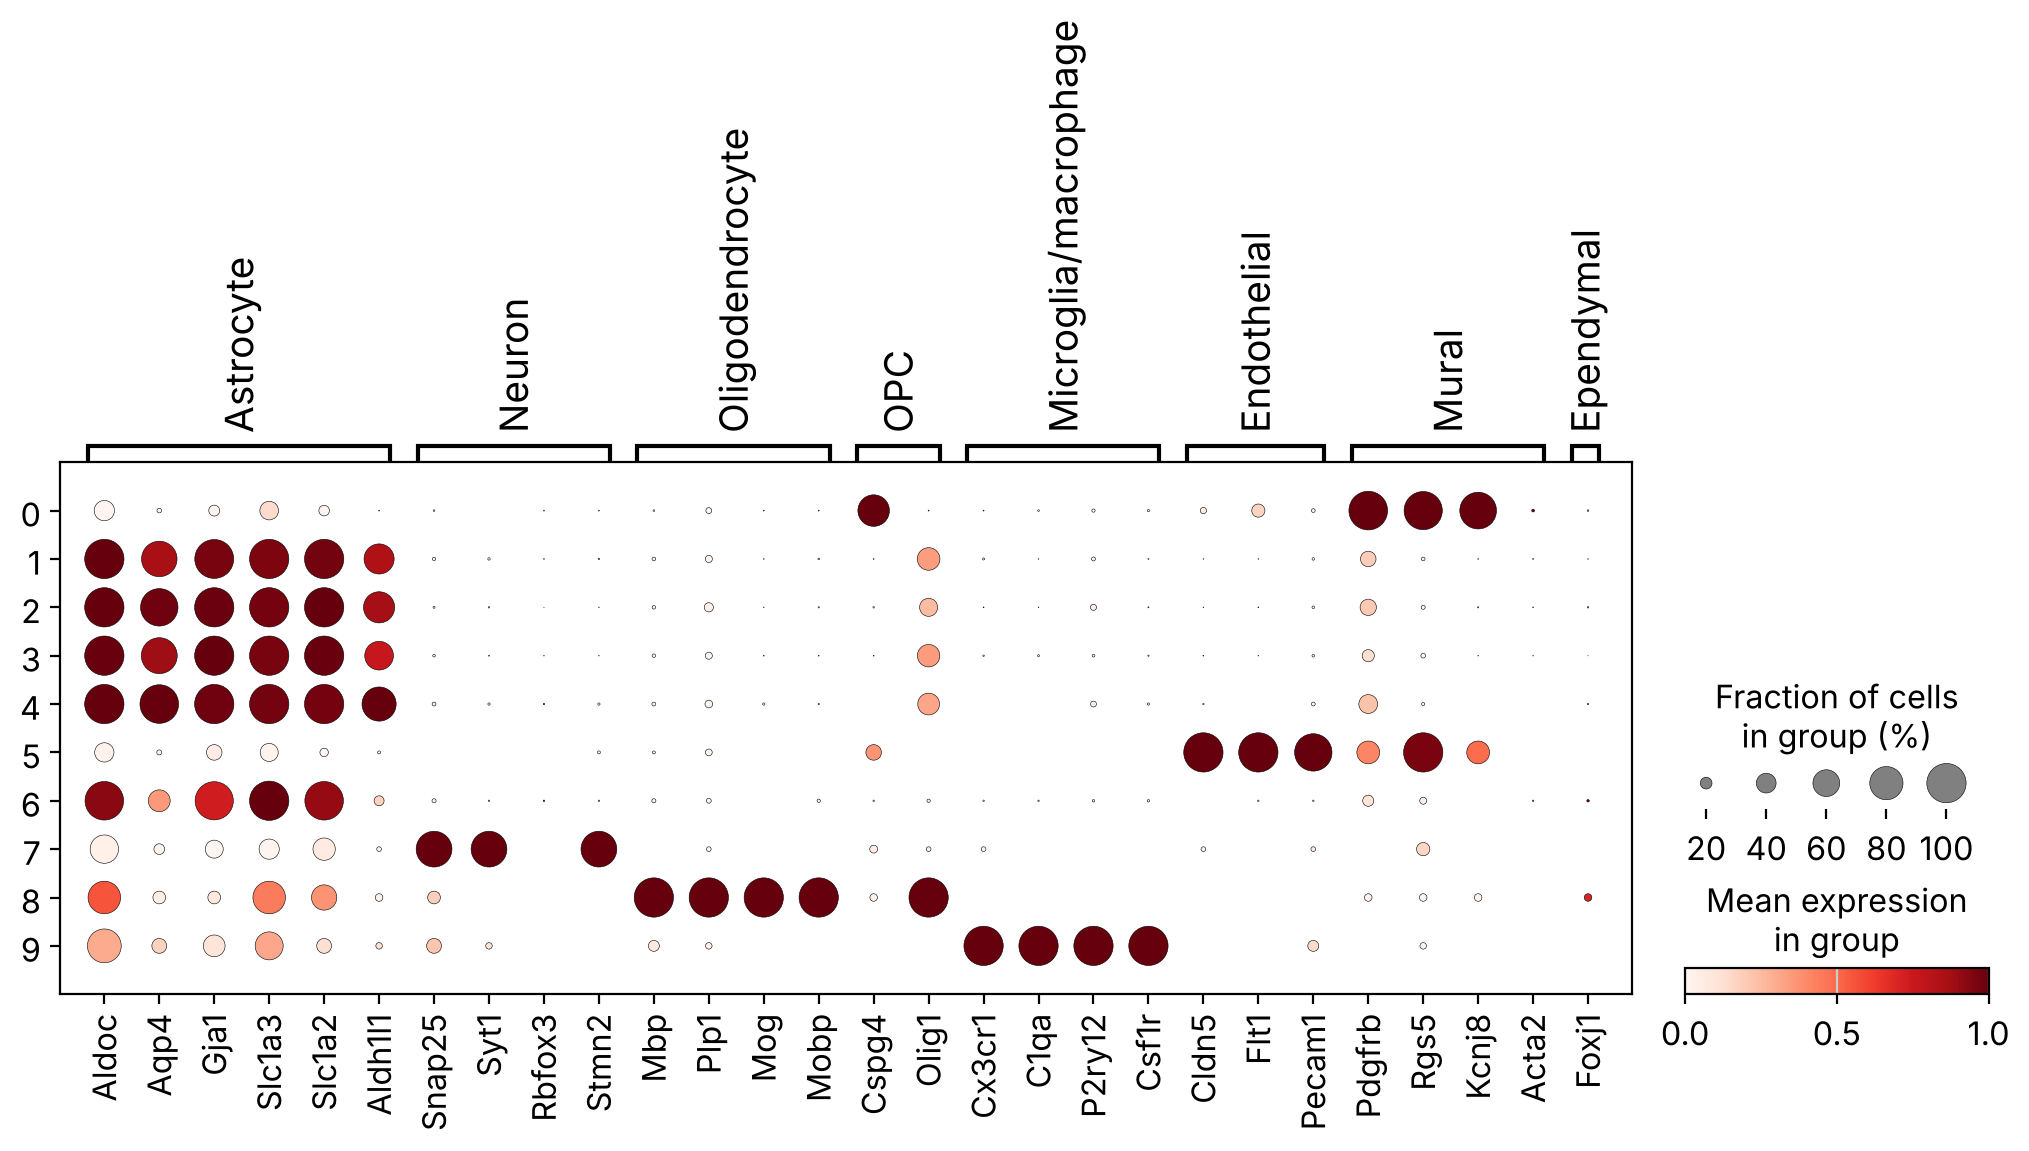

In [12]:
sc.pl.dotplot(adata, MARKERS, groupby="leiden", standard_scale="var", show=False)
plt.savefig(FIG / "03_marker_dotplot.png", dpi=200, bbox_inches="tight")
plt.show()

### Data-driven marker genes per cluster

A Wilcoxon rank-sum test of each cluster against all other cells, as an
independent check on the names given above.

In [13]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon", pts=True)
top = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(10)
top.columns = [f"{c} ({cluster_call[c]})" for c in top.columns]
top.to_csv(RES / "top10_markers_per_cluster.csv", index=False)
print(top.T.to_string(header=False))

0 (Mural)                   Cald1      Vtn  Igfbp7     Myl9     Nbl1      Rgs5    Sept4  Ndufa4l2  Serinc3    Pdgfrb
1 (Astrocyte)               Kcnk1   Btbd17   Htra1  Slco1c1    S1pr1        F3   Atp1b1    Chrdl1  Slc7a10     Msmo1
2 (Astrocyte)                 Id3      Clu    Apoe     Gfap     Lcat   Hsd11b1     Cst3       Mt1     Aqp4       Cpe
3 (Astrocyte)                 Agt  Sparcl1  Pla2g7    Itih3     Cd81      Nnat     Gja1     Sparc    Ednrb  Serpine2
4 (Astrocyte)                 Fos      Jun   Dusp1    Cyr61     Hes5     Mfge8    Luzp2      Junb  Ppp1r3g   Gm20421
5 (Endothelial)             Itm2a    Cldn5   Ly6c1  Slco1a4     Pltp      Flt1  Tsc22d1      Ly6e      Eng       Bsg
6 (Astrocyte)                 Dbi      Cd9  Notch2     Ass1   Gm5424     Rplp0    Sparc      Gfap   Maged1    Tuba1a
7 (Neuron)                Slc17a6     Pcp4    Reln   Snhg11  Dync1i1      Ndnf    Map1b    Atp1a3    Stmn1    Prune2
8 (Oligodendrocyte)          Qdpr      Mal   Aplp1    Kcna1     

### Agreement with the published broad cell types

The authors label non-astrocyte cells by type and astrocytes as AST1 to AST5.
For this comparison all AST labels are collapsed to "Astrocyte".

In [14]:
def broad(label):
    return "Astrocyte" if str(label).startswith("AST") else str(label)

adata.obs["published_broad"] = adata.obs["published_type"].map(broad)
broad_table = pd.crosstab(adata.obs["cell_type"], adata.obs["published_broad"])
broad_table.to_csv(RES / "celltype_vs_published_broad.csv")
print(broad_table.to_string())
is_astro_mine = adata.obs["cell_type"] == "Astrocyte"
is_astro_pub = adata.obs["published_broad"] == "Astrocyte"
agree = float((is_astro_mine == is_astro_pub).mean())
print(f"\nAstrocyte versus non-astrocyte agreement with the published labels: {agree:.1%}")

published_broad       (none)  Astrocyte  Endothelial  Microglial  Mural  Neuronal  Oligodendrocytic
cell_type                                                                                          
Astrocyte                 13       1782            0           0      0         0                 0
Endothelial                0          0           30           0      1         0                 0
Microglia/macrophage       0          0            0          11      0         0                 0
Mural                      0          2            0           0    136         0                 0
Neuron                     0          0            0           0      0        17                 0
Oligodendrocyte            0          0            0           0      0         0                 9

Astrocyte versus non-astrocyte agreement with the published labels: 99.3%


## 6. Astrocyte subtypes

The cells called astrocytes here are taken forward, highly variable genes are
re-selected within them and they are clustered again. The published subtype
labels (AST1 to AST5) are then used as the reference.

In [15]:
astro = adata[adata.obs["cell_type"] == "Astrocyte"].copy()
astro.X = astro.layers["counts"].copy()
astro.uns.pop("log1p", None)  # X holds raw counts again, so clear the log1p flag
sc.pp.filter_genes(astro, min_cells=5)
sc.pp.normalize_total(astro)
sc.pp.log1p(astro)
sc.pp.highly_variable_genes(astro, n_top_genes=2000, flavor="seurat")
sc.tl.pca(astro, n_comps=30, mask_var="highly_variable", random_state=SEED)
sc.pp.neighbors(astro, n_neighbors=15, n_pcs=15, random_state=SEED)
sc.tl.umap(astro, random_state=SEED)
print("astrocytes analysed:", astro.n_obs)

rows = []
has_pub = astro.obs["published_type"].str.startswith("AST").values
for res in [0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]:
    key = f"leiden_{res}"
    sc.tl.leiden(astro, resolution=res, key_added=key, flavor="igraph", n_iterations=2, directed=False, random_state=SEED)
    rows.append(
        {
            "resolution": res,
            "clusters": astro.obs[key].nunique(),
            "ARI": adjusted_rand_score(astro.obs["published_type"][has_pub], astro.obs[key][has_pub]),
            "NMI": normalized_mutual_info_score(astro.obs["published_type"][has_pub], astro.obs[key][has_pub]),
        }
    )
sweep = pd.DataFrame(rows)
sweep.to_csv(RES / "astrocyte_resolution_sweep.csv", index=False)
print(sweep.round(3).to_string(index=False))

astrocytes analysed: 1795


 resolution  clusters   ARI   NMI
        0.2         3 0.103 0.301
        0.3         4 0.315 0.439
        0.4         4 0.342 0.403
        0.5         5 0.258 0.359
        0.6         6 0.311 0.367
        0.8        10 0.212 0.328
        1.0        13 0.175 0.318


The resolution is not tuned to the published answer. It is fixed at the value
that gives five clusters (the number of subtypes the paper reports); if several
values give five, the lowest is used. The sweep above shows how much the
agreement depends on that choice.

In [16]:
five = sweep[sweep["clusters"] == 5]
RES_CHOSEN = float(five["resolution"].min()) if len(five) else float(sweep.iloc[(sweep["clusters"] - 5).abs().argsort().iloc[0]]["resolution"])
astro.obs["subcluster"] = astro.obs[f"leiden_{RES_CHOSEN}"].astype("category")
ari = adjusted_rand_score(astro.obs["published_type"][has_pub], astro.obs["subcluster"][has_pub])
nmi = normalized_mutual_info_score(astro.obs["published_type"][has_pub], astro.obs["subcluster"][has_pub])
print(f"resolution used: {RES_CHOSEN} -> {astro.obs['subcluster'].nunique()} clusters; ARI = {ari:.3f}; NMI = {nmi:.3f}")

resolution used: 0.5 -> 5 clusters; ARI = 0.258; NMI = 0.359


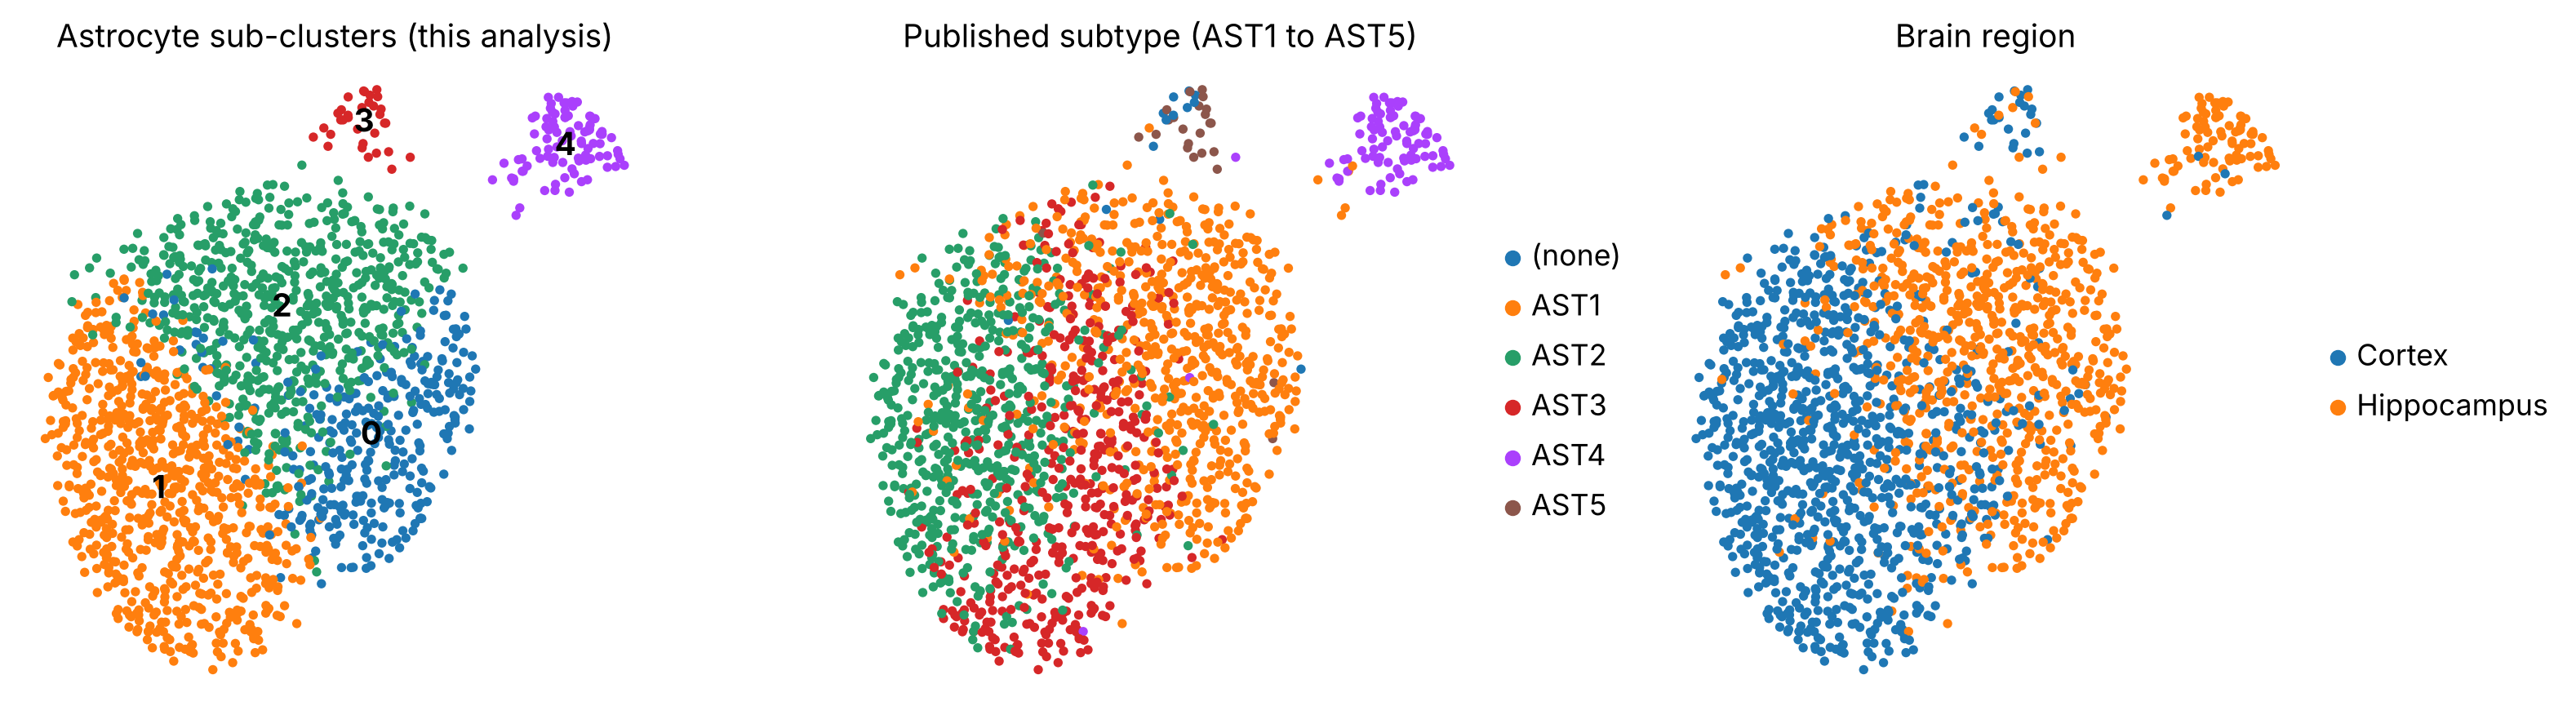

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
sc.pl.umap(astro, color="subcluster", ax=axes[0], show=False, title="Astrocyte sub-clusters (this analysis)", legend_loc="on data")
sc.pl.umap(astro, color="published_type", ax=axes[1], show=False, title="Published subtype (AST1 to AST5)")
sc.pl.umap(astro, color="region", ax=axes[2], show=False, title="Brain region")
fig.tight_layout()
fig.savefig(FIG / "04_umap_astrocytes.png", dpi=200, bbox_inches="tight")
plt.show()

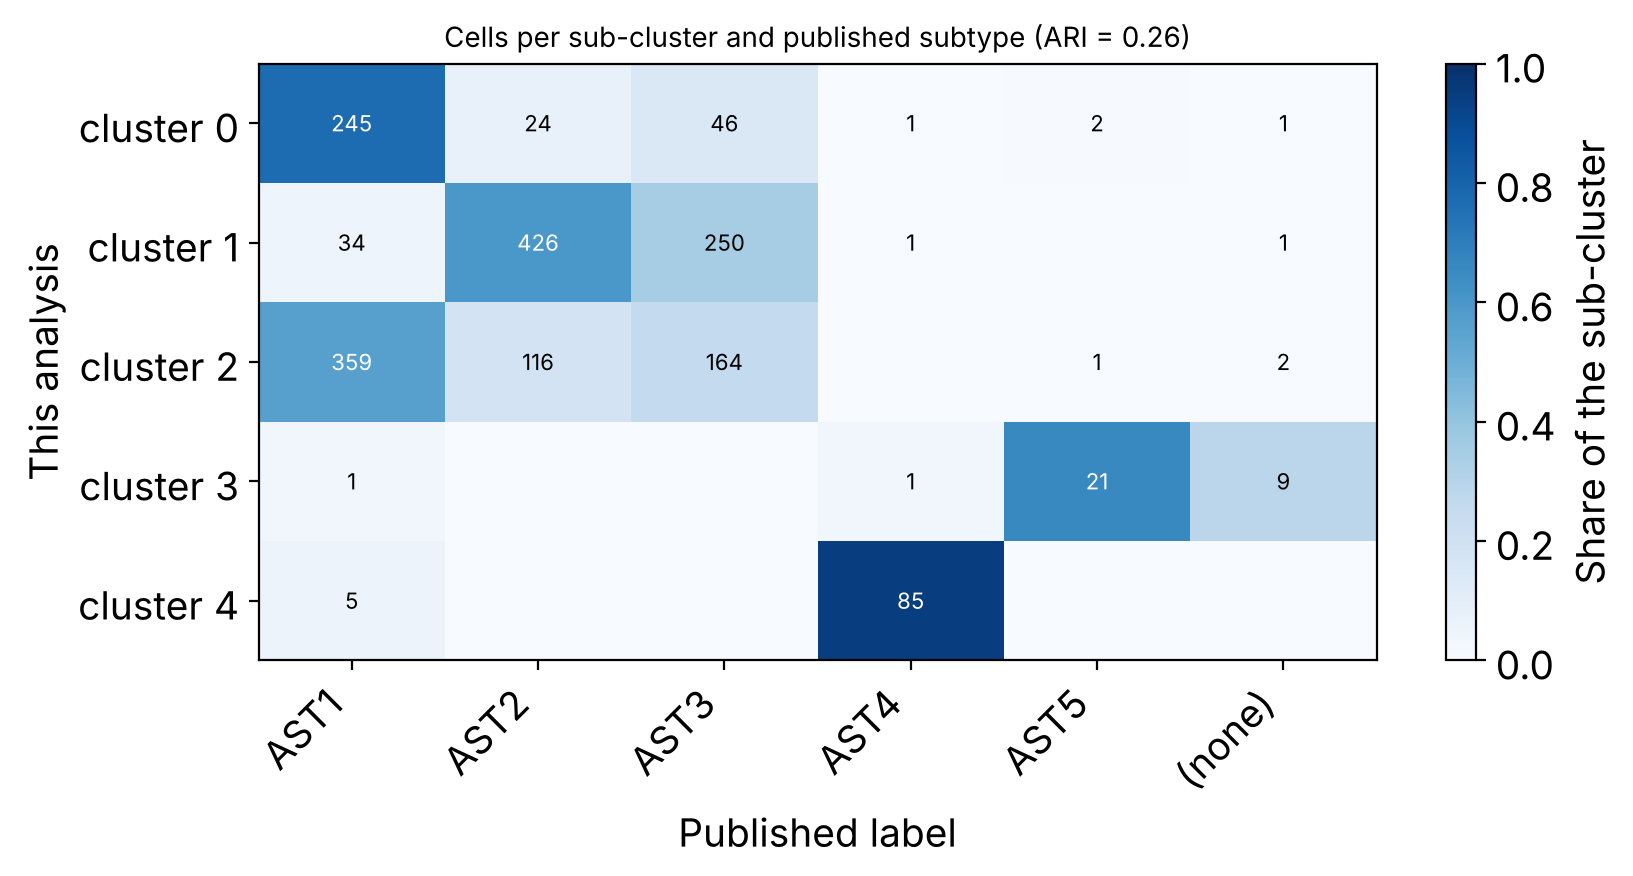

published_type  AST1  AST2  AST3  AST4  AST5  (none)
subcluster                                          
0                245    24    46     1     2       1
1                 34   426   250     1     0       1
2                359   116   164     0     1       2
3                  1     0     0     1    21       9
4                  5     0     0    85     0       0


In [18]:
conf = pd.crosstab(astro.obs["subcluster"], astro.obs["published_type"])
conf = conf[[c for c in conf.columns if c.startswith("AST")] + [c for c in conf.columns if not c.startswith("AST")]]
conf.to_csv(RES / "astrocyte_subclusters_vs_published.csv")
frac = conf.div(conf.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(1.1 * conf.shape[1] + 2, 0.6 * conf.shape[0] + 1.6))
im = ax.imshow(frac.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(conf.shape[1]))
ax.set_xticklabels(conf.columns, rotation=45, ha="right")
ax.set_yticks(range(conf.shape[0]))
ax.set_yticklabels([f"cluster {i}" for i in conf.index])
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        v = int(conf.values[i, j])
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=8, color="white" if frac.values[i, j] > 0.55 else "black")
ax.set_xlabel("Published label")
ax.set_ylabel("This analysis")
ax.set_title(f"Cells per sub-cluster and published subtype (ARI = {ari:.2f})", fontsize=10)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Share of the sub-cluster")
fig.tight_layout()
fig.savefig(FIG / "05_subcluster_vs_published.png", dpi=200, bbox_inches="tight")
plt.show()
print(conf.to_string())

### Region composition and marker genes of the sub-clusters

The paper's central finding is that astrocyte subtypes differ between cortex
and hippocampus. The composition of each sub-cluster by region shows whether
this simple re-analysis sees the same thing.

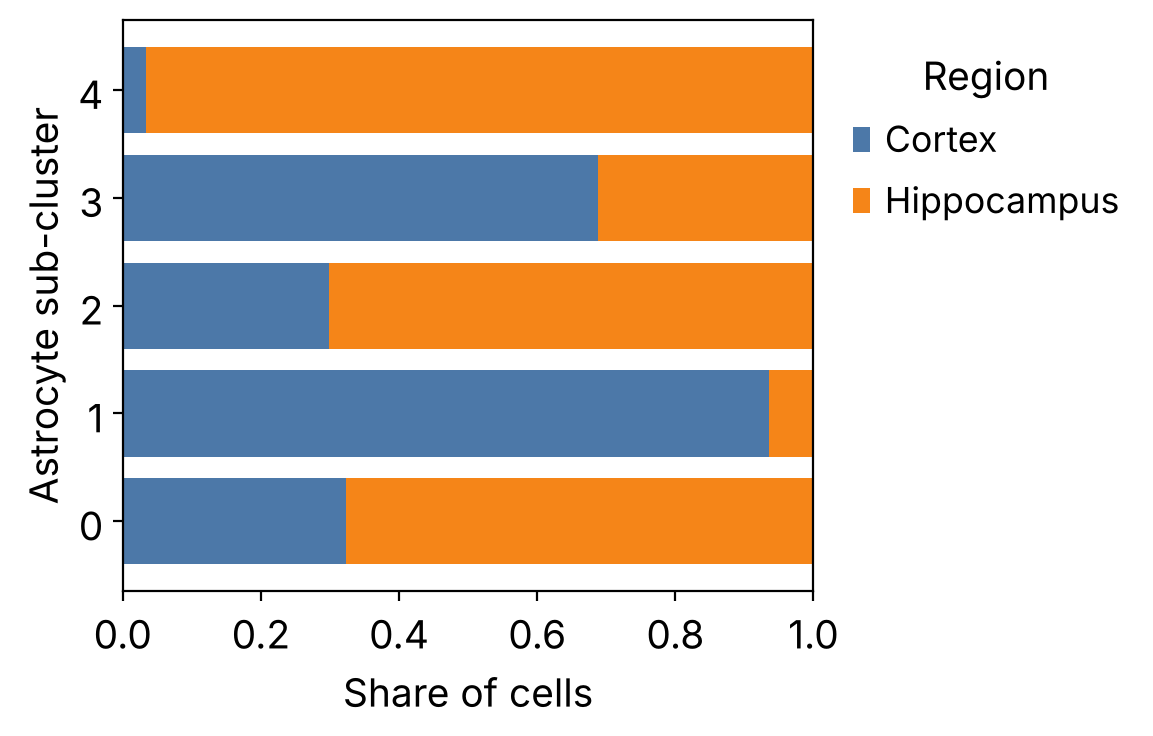

region      Cortex  Hippocampus  hippocampus_share
subcluster                                        
0              103          216               0.68
1              666           46               0.06
2              192          450               0.70
3               22           10               0.31
4                3           87               0.97


In [19]:
comp = pd.crosstab(astro.obs["subcluster"], astro.obs["region"])
comp_frac = comp.div(comp.sum(axis=1), axis=0)
comp.to_csv(RES / "astrocyte_subclusters_by_region.csv")
ax = comp_frac.plot(kind="barh", stacked=True, figsize=(6, 0.5 * comp.shape[0] + 1.4), color=["#4C78A8", "#F58518"], width=0.8)
ax.set_xlabel("Share of cells")
ax.set_ylabel("Astrocyte sub-cluster")
ax.set_xlim(0, 1)
ax.legend(title="Region", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(FIG / "06_subcluster_region_composition.png", dpi=200, bbox_inches="tight")
plt.show()
print(comp.assign(hippocampus_share=comp_frac.get("Hippocampus", 0).round(2)).to_string())

cluster 0      Id3   Apoe     Clu    Gfap       Mt1   Lcat     Cst3       Aqp4   Pantr1   Tprkb
cluster 1   Btbd17  Kcnk1  Igfbp2   Luzp2   Slco1c1  Htra1    Pmp22     Chrdl1  Slc38a3  Atp1b1
cluster 2  Sparcl1    Agt   Sparc    Cd81  Serpine2   Gja1  Selenop       Cst3     Nnat   Ednrb
cluster 3    Aldoc    Cpe    Fth1     Mt3       Mt1  Ndrg2     Cfl1  Rn18s-rs5  Gm13493   Gstm1
cluster 4      Dbi    Cd9   Sparc  Notch2    Gm5424   Ass1     Ptma     Tuba1a   Gm9800  Eef1a1


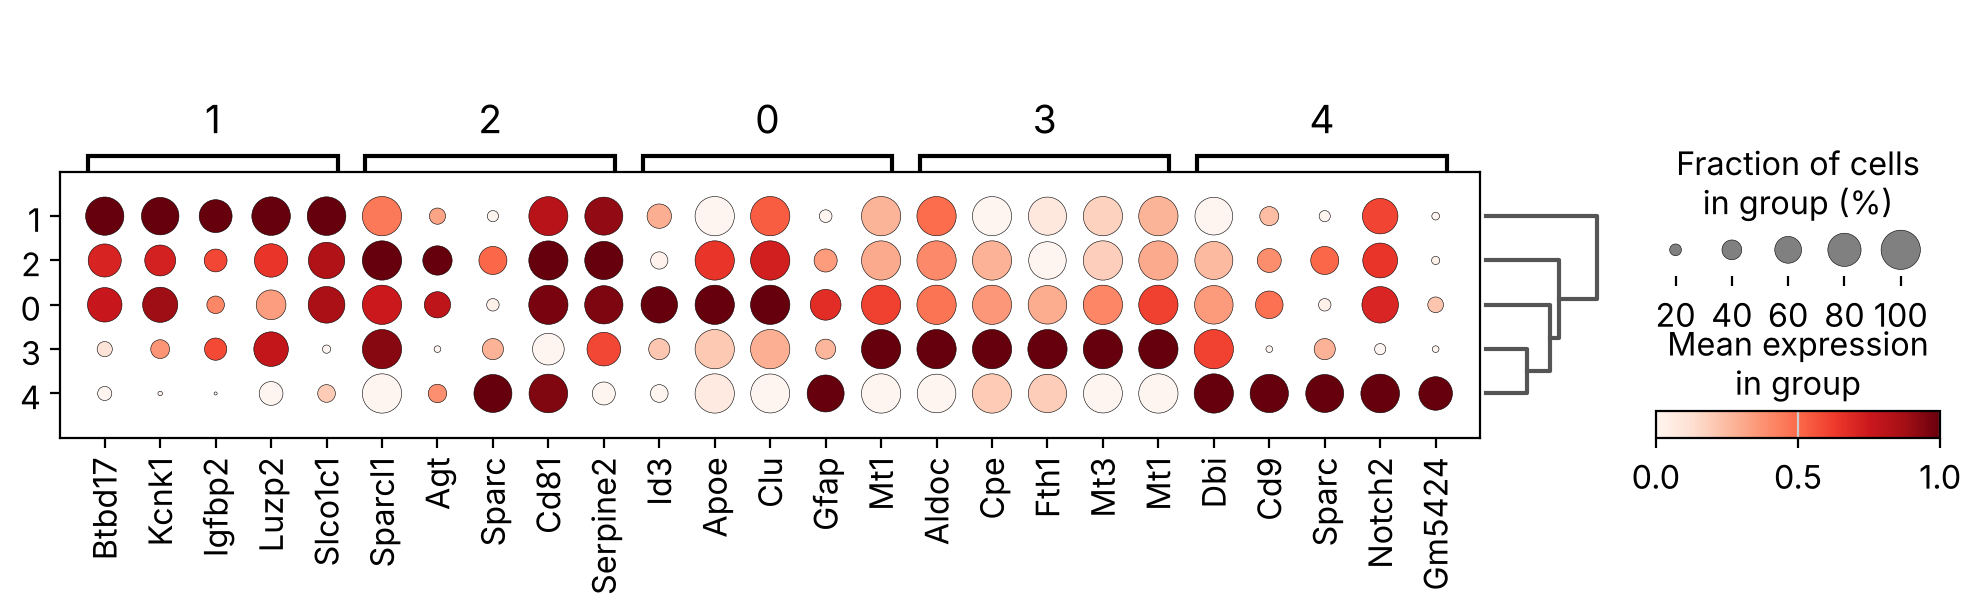

In [20]:
sc.tl.rank_genes_groups(astro, "subcluster", method="wilcoxon", pts=True)
sub_top = pd.DataFrame(astro.uns["rank_genes_groups"]["names"]).head(15)
sub_top.columns = [f"cluster {c}" for c in sub_top.columns]
sub_top.to_csv(RES / "astrocyte_subcluster_top15_markers.csv", index=False)
print(sub_top.head(10).T.to_string(header=False))
sc.tl.dendrogram(astro, "subcluster")
sc.pl.rank_genes_groups_dotplot(astro, n_genes=5, standard_scale="var", show=False)
plt.savefig(FIG / "07_subcluster_marker_dotplot.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. A technical confound worth checking: dissociation-induced genes

Enzymatic tissue dissociation switches on immediate-early genes (Fos, Jun,
Egr1 and others) in some cells. That signal is a preparation artefact, not
resting biology, and it can form its own cluster. Scoring it per cell shows
where it sits. In work on stress-related disorders this matters twice over,
because the same genes also respond to real stress in vivo.

genes in the score: Fos, Fosb, Jun, Junb, Jund, Egr1, Ier2, Ier3, Dusp1, Atf3, Hspa1a, Hspa1b, Nr4a1, Klf2, Klf4, Btg2
        mean  median  size             cell_type
leiden                                          
0       2.72    2.76   138                 Mural
1      -0.39   -0.47   663             Astrocyte
2      -0.42   -0.49   481             Astrocyte
3      -0.37   -0.46   482             Astrocyte
4       1.37    1.25    88             Astrocyte
5       3.54    3.68    31           Endothelial
6       0.19   -0.23    81             Astrocyte
7       0.38    0.00    17                Neuron
8      -0.48   -0.38     9       Oligodendrocyte
9       4.01    4.26    11  Microglia/macrophage

            mean  size
subcluster            
0          -0.45   319
1          -0.19   712
2          -0.35   642
3          -0.39    32
4           0.14    90


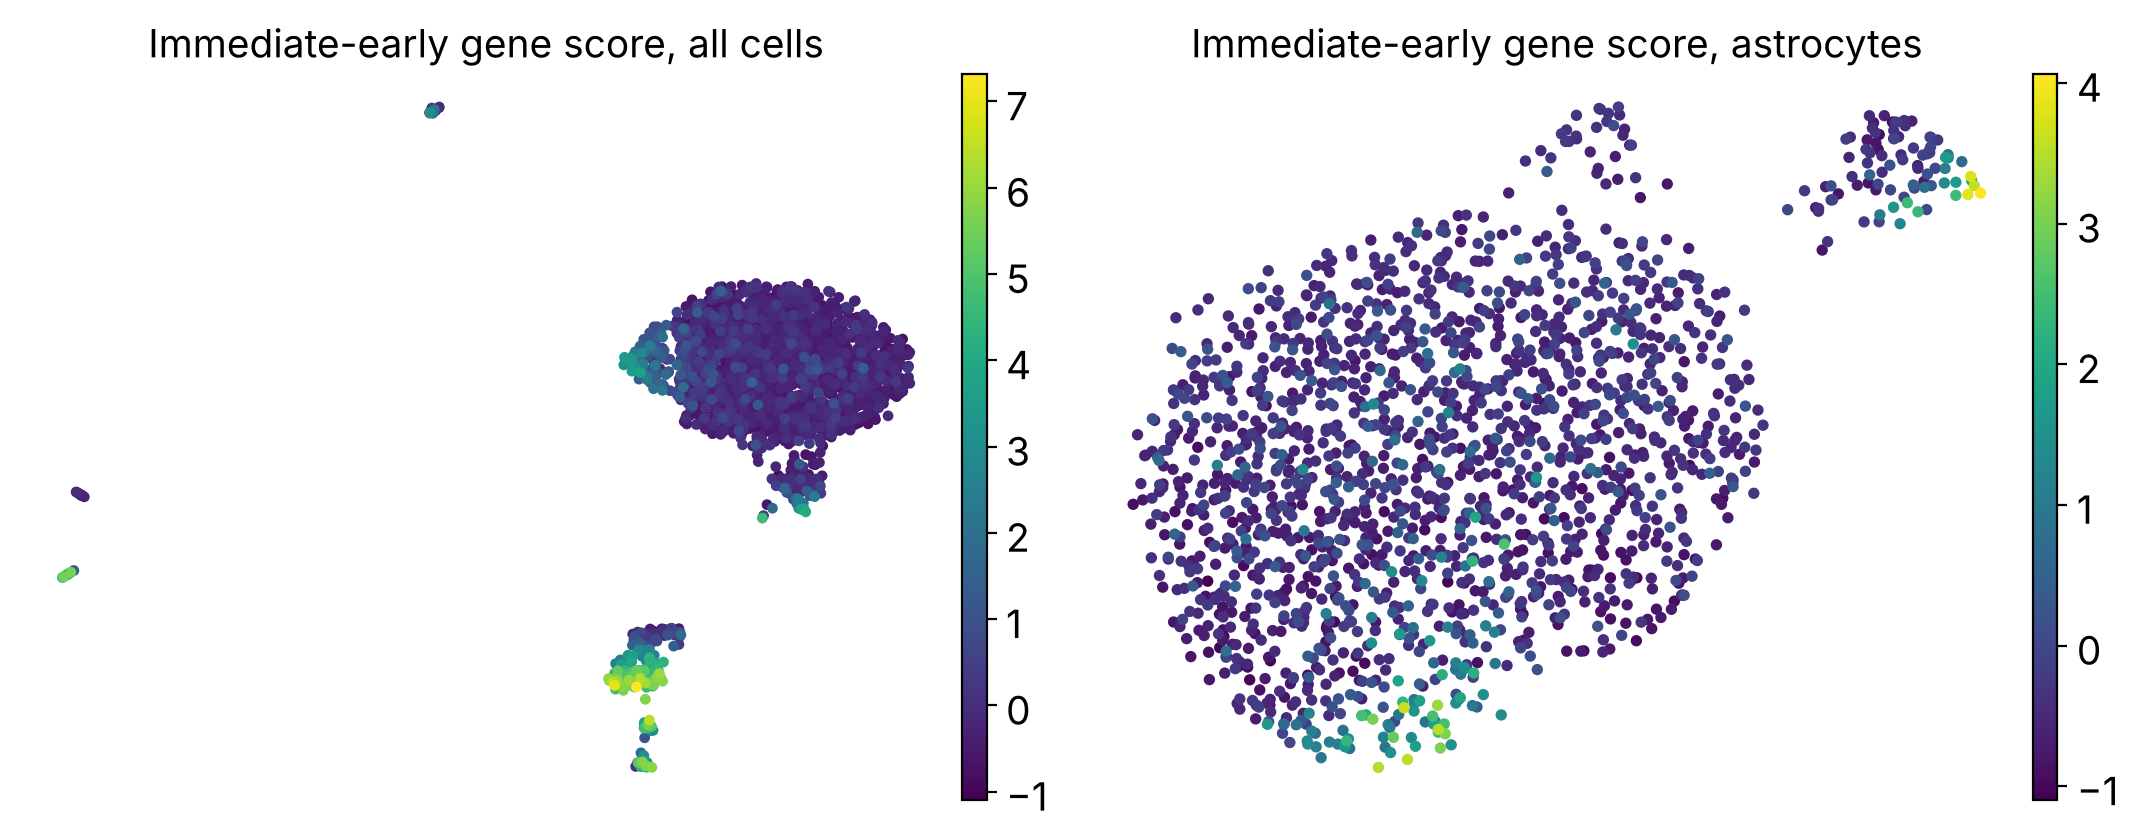

In [21]:
IEG = [g for g in ["Fos", "Fosb", "Jun", "Junb", "Jund", "Egr1", "Ier2", "Ier3", "Dusp1", "Atf3", "Hspa1a", "Hspa1b", "Nr4a1", "Klf2", "Klf4", "Btg2"] if g in adata.var_names]
sc.tl.score_genes(adata, IEG, score_name="ieg_score", random_state=SEED)
ieg_by_cluster = adata.obs.groupby("leiden", observed=True)["ieg_score"].agg(["mean", "median", "size"]).round(2)
ieg_by_cluster["cell_type"] = cluster_call
ieg_by_cluster.to_csv(RES / "ieg_score_by_cluster.csv")
print("genes in the score:", ", ".join(IEG))
print(ieg_by_cluster.to_string())
astro.obs["ieg_score"] = adata.obs["ieg_score"].reindex(astro.obs_names).values
print()
print(astro.obs.groupby("subcluster", observed=True)["ieg_score"].agg(["mean", "size"]).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
sc.pl.umap(adata, color="ieg_score", ax=axes[0], show=False, title="Immediate-early gene score, all cells", cmap="viridis")
sc.pl.umap(astro, color="ieg_score", ax=axes[1], show=False, title="Immediate-early gene score, astrocytes", cmap="viridis")
fig.tight_layout()
fig.savefig(FIG / "08_dissociation_ieg_score.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Summary of what the numbers say

In [22]:
summary = {
    "cells_in_deposited_matrix": int(n_before),
    "cells_after_qc": int(adata.n_obs),
    "genes_after_filtering": int(adata.n_vars),
    "leiden_clusters_all_cells": int(adata.obs["leiden"].nunique()),
    "cells_called_astrocyte": int(astro.n_obs),
    "astrocyte_vs_other_agreement_with_published": round(agree, 4),
    "astrocyte_subcluster_resolution": RES_CHOSEN,
    "astrocyte_subclusters": int(astro.obs["subcluster"].nunique()),
    "ARI_subclusters_vs_published_AST": round(float(ari), 4),
    "NMI_subclusters_vs_published_AST": round(float(nmi), 4),
    "ieg_high_cluster": str(ieg_by_cluster["mean"].idxmax()),
    "ieg_high_cluster_cells": int(ieg_by_cluster.loc[ieg_by_cluster["mean"].idxmax(), "size"]),
}
pd.Series(summary).to_csv(RES / "summary.csv", header=["value"])
for k, v in summary.items():
    print(f"{k}: {v}")
adata.obs.to_csv(RES / "cell_annotations_all_cells.csv")
astro.obs[["region", "plate", "published_type", "subcluster"]].to_csv(RES / "cell_annotations_astrocytes.csv")

cells_in_deposited_matrix: 2031
cells_after_qc: 2001
genes_after_filtering: 19980
leiden_clusters_all_cells: 10
cells_called_astrocyte: 1795
astrocyte_vs_other_agreement_with_published: 0.9925
astrocyte_subcluster_resolution: 0.5
astrocyte_subclusters: 5
ARI_subclusters_vs_published_AST: 0.2581
NMI_subclusters_vs_published_AST: 0.3594
ieg_high_cluster: 9
ieg_high_cluster_cells: 11
